In [1]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
!pip -q install tensorflow-datasets scikit-learn matplotlib

import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_datasets as tfds

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

In [5]:
IMG_SIZE = 160
BATCH_SIZE = 32
SEED = 42
CLASS_NAMES = ["rock", "paper", "scissors"]

AUTOTUNE = tf.data.AUTOTUNE

In [6]:
(ds_train_full, ds_test), ds_info = tfds.load(
    "rock_paper_scissors",
    split=["train", "test"],
    as_supervised=False,
    with_info=True
)

print(ds_info)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/rock_paper_scissors/incomplete.AIKIJ0_3.0.0/rock_paper_scissors-train.tfre…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/rock_paper_scissors/incomplete.AIKIJ0_3.0.0/rock_paper_scissors-test.tfrec…

Dataset rock_paper_scissors downloaded and prepared to /root/tensorflow_datasets/rock_paper_scissors/3.0.0. Subsequent calls will reuse this data.
tfds.core.DatasetInfo(
    name='rock_paper_scissors',
    full_name='rock_paper_scissors/3.0.0',
    description="""
    Images of hands playing rock, paper, scissor game.
    """,
    homepage='http://laurencemoroney.com/rock-paper-scissors-dataset',
    data_dir='/root/tensorflow_datasets/rock_paper_scissors/3.0.0',
    file_format=tfrecord,
    download_size=219.53 MiB,
    dataset_size=219.23 MiB,
    features=FeaturesDict({
        'image': Image(shape=(300, 300, 3), dtype=uint8),
        'label': ClassLabel(shape=(), dtype=int64, num_classes=3),
    }),
    supervised_keys=('image', 'label'),
    disable_shuffling=False,
    nondeterministic_order=False,
    splits={
        'test': <SplitInfo num_examples=372, num_shards=1>,
        'train': <SplitInfo num_examples=2520, num_shards=2>,
    },
    citation="""@ONLINE {rps,
    author 

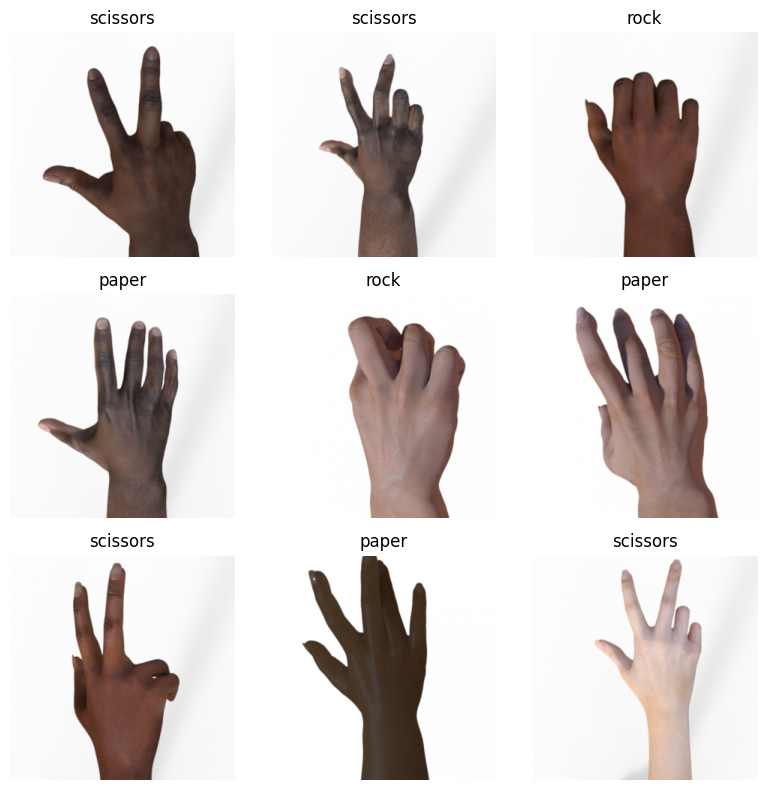

In [7]:
def show_samples(dataset, n=9):
    plt.figure(figsize=(8,8))
    for i, example in enumerate(dataset.take(n)):
        img = example["image"].numpy()
        label = example["label"].numpy()
        plt.subplot(3,3,i+1)
        plt.imshow(img)
        plt.title(CLASS_NAMES[label])
        plt.axis("off")
    plt.tight_layout()
    plt.show()

show_samples(ds_train_full, n=9)

In [10]:
def preprocess(example):
    img = tf.image.resize(example["image"], (IMG_SIZE, IMG_SIZE))
    img = tf.cast(img, tf.float32) / 255.0   # normalize to [0,1]
    label = tf.cast(example["label"], tf.int32)
    return img, label

def augment(img, label):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_brightness(img, 0.15)
    img = tf.image.random_contrast(img, 0.8, 1.2)
    return img, label

In [14]:
train_size = tf.data.experimental.cardinality(ds_train_full).numpy()
val_size = int(0.15 * train_size)

ds_train_full = ds_train_full.shuffle(5000, seed=SEED, reshuffle_each_iteration=True)
ds_val = ds_train_full.take(val_size)
ds_train = ds_train_full.skip(val_size)

ds_train = (ds_train
            .map(preprocess, num_parallel_calls=AUTOTUNE)
            .map(augment, num_parallel_calls=AUTOTUNE)
            .batch(BATCH_SIZE)
            .prefetch(AUTOTUNE))

ds_val = (ds_val
          .map(preprocess, num_parallel_calls=AUTOTUNE)
          .batch(BATCH_SIZE)
          .prefetch(AUTOTUNE))

ds_test = (ds_test
           .map(preprocess, num_parallel_calls=AUTOTUNE)
           .batch(BATCH_SIZE)
           .prefetch(AUTOTUNE))

print("Train batches:", tf.data.experimental.cardinality(ds_train).numpy())
print("Val batches:", tf.data.experimental.cardinality(ds_val).numpy())
print("Test batches:", tf.data.experimental.cardinality(ds_test).numpy())


Train batches: 67
Val batches: 12
Test batches: 12


In [11]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights="imagenet"
)
base_model.trainable = False  # Stage 1: freeze backbone

inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = tf.keras.applications.mobilenet_v2.preprocess_input(inputs * 255.0)
x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.2)(x)
outputs = tf.keras.layers.Dense(3, activation="softmax")(x)

model = tf.keras.Model(inputs, outputs)
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ multiply (Multiply)             │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,261,827 (8.63 MB)

 Trainable params: 3,843 (15.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [15]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint("rps_mobilenetv2.keras", save_best_only=True),
]

history1 = model.fit(
    ds_train,
    validation_data=ds_val,
    epochs=10,
    callbacks=callbacks
)

Epoch 1/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 52s 453ms/step - accuracy: 0.6774 - loss: 0.7387 - val_accuracy: 0.9947 - val_loss: 0.0893
Epoch 2/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.9822 - loss: 0.0996 - val_accuracy: 0.9974 - val_loss: 0.0429
Epoch 3/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.9864 - loss: 0.0662 - val_accuracy: 0.9974 - val_loss: 0.0280
Epoch 4/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.9948 - loss: 0.0409 - val_accuracy: 0.9974 - val_loss: 0.0192
Epoch 5/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.9946 - loss: 0.0296 - val_accuracy: 1.0000 - val_loss: 0.0146
Epoch 6/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.9959 - loss: 0.0233 - val_accuracy: 1.0000 - val_loss: 0.0088
Epoch 7/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.9982 - loss: 0.0186 - val_accuracy: 1.0000 - val_loss: 0.0070
Epoch 8/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.9992 - loss: 0.0122 - val_accuracy: 1.0000 -

In [16]:
base_model.trainable = True

# Freeze most layers, unfreeze only the last ~30 for safe fine-tuning
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),  # smaller LR for fine-tuning
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history2 = model.fit(
    ds_train,
    validation_data=ds_val,
    epochs=8,
    callbacks=callbacks
)

Epoch 1/8
67/67 ━━━━━━━━━━━━━━━━━━━━ 37s 287ms/step - accuracy: 0.9578 - loss: 0.1048 - val_accuracy: 1.0000 - val_loss: 0.0038
Epoch 2/8
67/67 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - accuracy: 0.9972 - loss: 0.0068 - val_accuracy: 1.0000 - val_loss: 0.0018
Epoch 3/8
67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 1.0000 - loss: 4.8001e-04 - val_accuracy: 1.0000 - val_loss: 8.2225e-04
Epoch 4/8
67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.9996 - loss: 0.0014 - val_accuracy: 1.0000 - val_loss: 7.6309e-04
Epoch 5/8
67/67 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - accuracy: 0.9991 - loss: 0.0018 - val_accuracy: 1.0000 - val_loss: 0.0021
Epoch 6/8
67/67 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 1.0000 - loss: 3.1608e-04 - val_accuracy: 1.0000 - val_loss: 7.6213e-04
Epoch 7/8
67/67 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - accuracy: 1.0000 - loss: 4.5078e-04 - val_accuracy: 1.0000 - val_loss: 3.5467e-04
Epoch 8/8
67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 1.0000 - loss: 1.1733e-04 

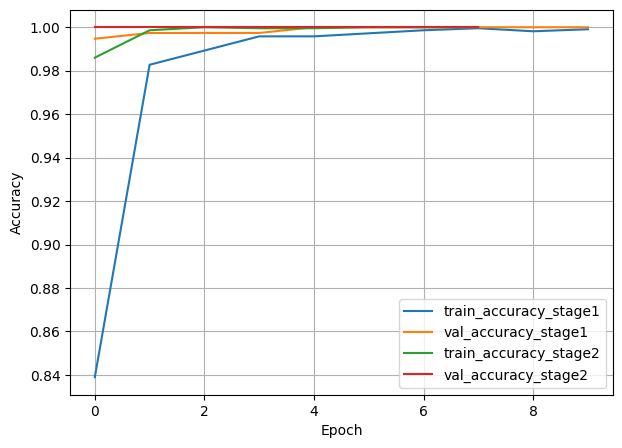

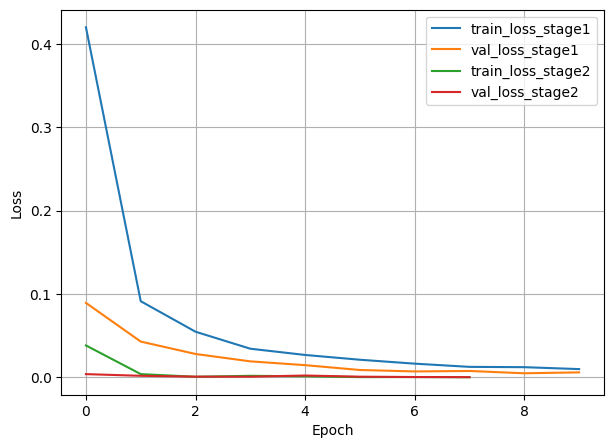

In [17]:
def plot_history(histories, metric="accuracy"):
    plt.figure(figsize=(7,5))
    for i, h in enumerate(histories, start=1):
        plt.plot(h.history[metric], label=f"train_{metric}_stage{i}")
        plt.plot(h.history["val_" + metric], label=f"val_{metric}_stage{i}")
    plt.xlabel("Epoch")
    plt.ylabel(metric.capitalize())
    plt.legend()
    plt.grid(True)
    plt.show()

plot_history([history1, history2], metric="accuracy")
plot_history([history1, history2], metric="loss")

In [18]:
best_model = tf.keras.models.load_model("rps_mobilenetv2.keras")

test_loss, test_acc = best_model.evaluate(ds_test)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

12/12 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - accuracy: 0.8769 - loss: 0.3089
Test Loss: 0.3201
Test Accuracy: 0.8737


<Figure size 600x600 with 0 Axes>

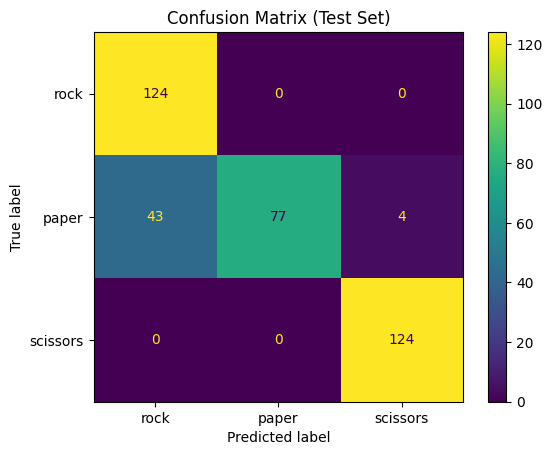

              precision    recall  f1-score   support

        rock     0.7425    1.0000    0.8522       124
       paper     1.0000    0.6210    0.7662       124
    scissors     0.9688    1.0000    0.9841       124

    accuracy                         0.8737       372
   macro avg     0.9038    0.8737    0.8675       372
weighted avg     0.9038    0.8737    0.8675       372



In [19]:
y_true = []
y_pred = []

for imgs, labels in ds_test:
    preds = best_model.predict(imgs, verbose=0)
    preds_cls = np.argmax(preds, axis=1)
    y_true.extend(labels.numpy().tolist())
    y_pred.extend(preds_cls.tolist())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

cm = confusion_matrix(y_true, y_pred, labels=[0,1,2])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)

plt.figure(figsize=(6,6))
disp.plot(values_format="d")
plt.title("Confusion Matrix (Test Set)")
plt.show()

print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))

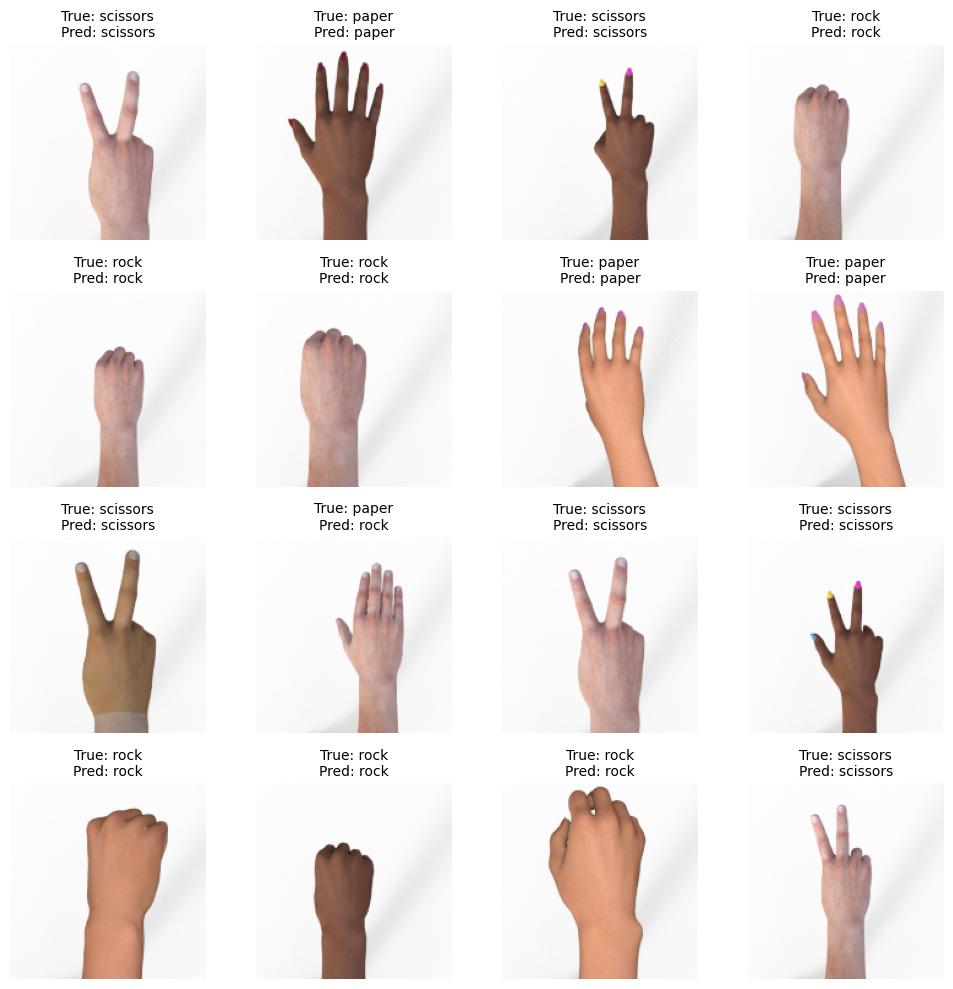

In [20]:
for imgs, labels in ds_test.take(1):
    preds = best_model.predict(imgs, verbose=0)
    preds_cls = np.argmax(preds, axis=1)

    plt.figure(figsize=(10,10))
    for i in range(16):
        plt.subplot(4,4,i+1)
        plt.imshow((imgs[i].numpy() * 255).astype(np.uint8))
        t = CLASS_NAMES[int(labels[i].numpy())]
        p = CLASS_NAMES[int(preds_cls[i])]
        plt.title(f"True: {t}\nPred: {p}", fontsize=10)
        plt.axis("off")
    plt.tight_layout()
    plt.show()